In [5]:
import pandas as pd

# 1) Import pandas and read in the banklist.csv file into a dataframe called banks.
# Note: Ensure the filename matches your local file (e.g., 'banklist (1).csv')
banks = pd.read_csv('banklist.csv')

# 2) Show the head of the dataframe.
print("--- 2) Head of the Dataframe ---")
print(banks.head())

# 3) What are the column names?
print("\n--- 3) Column Names ---")
print(banks.columns)

# 4) How many States (ST) are represented in this data set?
num_states = banks['ST'].nunique()
print(f"\n4) Number of unique states: {num_states}")

# 5) Get a list or array of all the states in the data set.
states = banks['ST'].unique()
print("\n--- 5) List of States ---")
print(states)

# 6) What are the top 5 states with the most failed banks?
top_5_states = banks['ST'].value_counts().head(5)
print("\n--- 6) Top 5 states with most failed banks ---")
print(top_5_states)

# 7) What are the top 5 acquiring institutions?
top_5_acquirers = banks['Acquiring Institution'].value_counts().head(5)
print("\n--- 7) Top 5 acquiring institutions ---")
print(top_5_acquirers)

# 8) How many banks has the State Bank of Texas acquired? 
# How many of them were actually in Texas?
state_bank_texas = banks[banks['Acquiring Institution'] == 'State Bank of Texas']
num_acquired = len(state_bank_texas)
num_in_tx = len(state_bank_texas[state_bank_texas['ST'] == 'TX'])

print(f"\n8) State Bank of Texas acquisitions: {num_acquired}")
print(f"   Acquisitions actually in Texas: {num_in_tx}")

# 9) What is the most common city in California for a bank to fail in?
ca_failed_banks = banks[banks['ST'] == 'CA']
most_common_city_ca = ca_failed_banks['City'].value_counts().idxmax()
print(f"\n9) Most common city in California for bank failure: {most_common_city_ca}")

--- 2) Head of the Dataframe ---
                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  
0   1802            United Fidelity Bank, fsb    26-May-17    26-Jul-17  
1  30003  First-Citizens Bank & Trust Company     5-May-17    26-Jul-17  
2  58302                         Whitney Bank    28-Apr-17    26-Jul-17  
3  35495                    Cache Valley Bank     3-Mar-17    18-May-17  
4  19328                  State Bank of Texas    27-Jan-17    18-May-17  

--- 3) Column Names ---
Index(['Bank Name

In [3]:
#--------------------Assesment 2------------------------

# Q 1: Develop a Line chart using the functionality of pandas to show how
# automobile sales fluctuate from year to year.
# Q 2: Plot different lines for categories of vehicle type and analyze the trend
# to answer the question Is there a noticeable difference in sales trends
# between different vehicle types during recession periods?
# Q 3: Use the functionality of Seaborn Library to create a visualization to compare
# the sales trend per vehicle type for a recession period with a non- recession
# period.
# Q 4: Now you want to compare the sales of different vehicle types
# during a recession and a non-recession period 

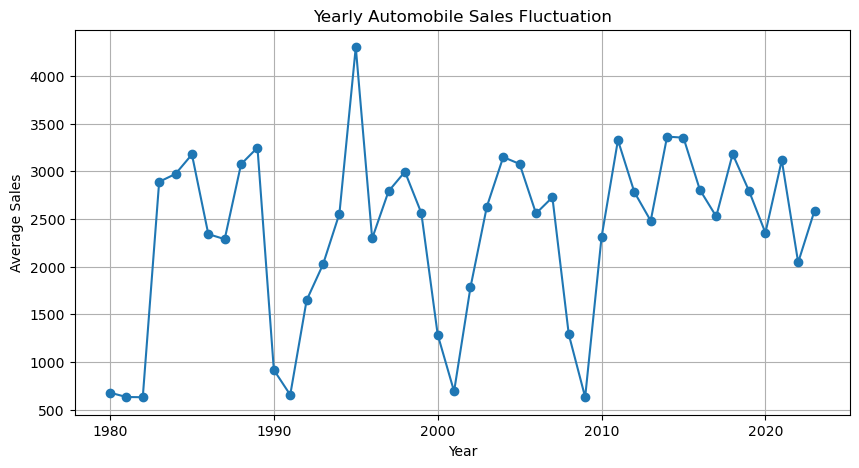

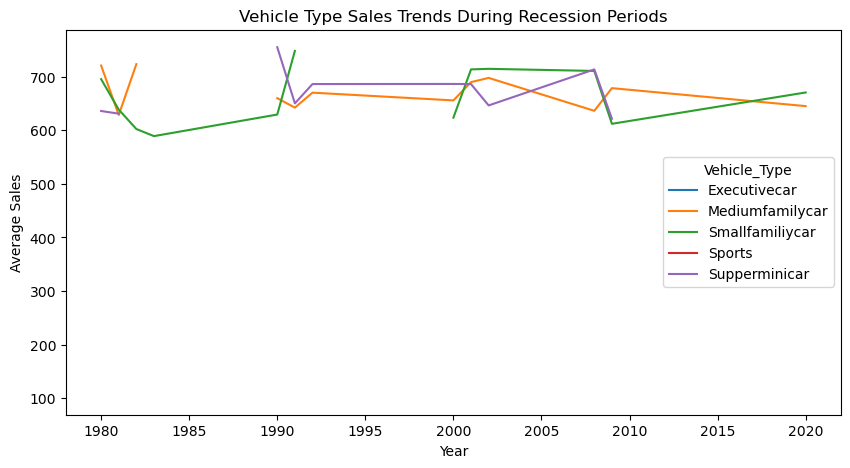

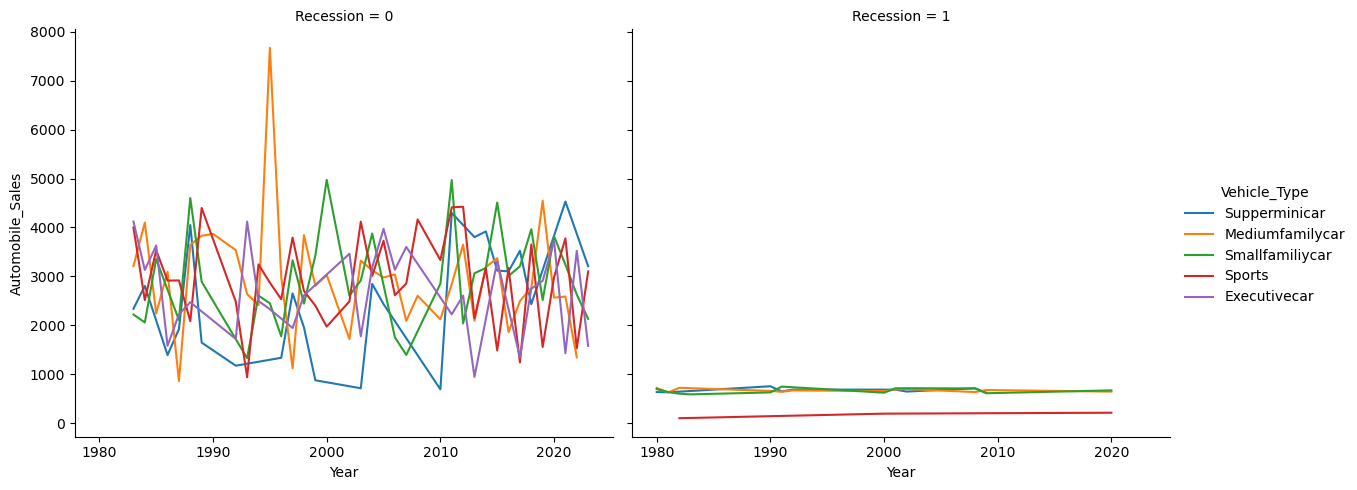

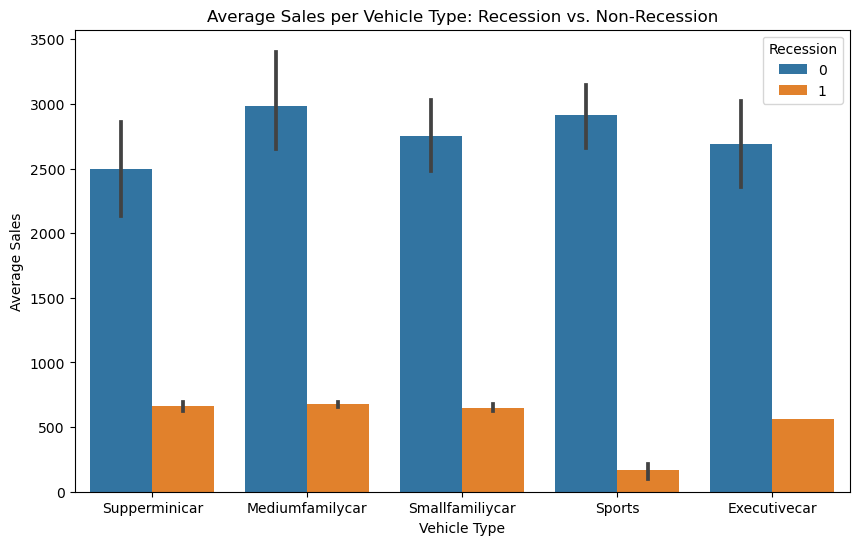

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('historical_automobile_sales.csv')

# Q 1: Line chart for year-to-year sales
yearly_sales = df.groupby('Year')['Automobile_Sales'].mean()
plt.figure(figsize=(10, 5))
yearly_sales.plot(kind='line', marker='o')
plt.title('Yearly Automobile Sales Fluctuation')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.grid(True)
plt.savefig('yearly_sales.png')

# Q 2: Sales trends by Vehicle Type during Recession
recession_data = df[df['Recession'] == 1]
vt_recession = recession_data.groupby(['Year', 'Vehicle_Type'])['Automobile_Sales'].mean().unstack()
plt.figure(figsize=(10, 5))
vt_recession.plot(kind='line', ax=plt.gca())
plt.title('Vehicle Type Sales Trends During Recession Periods')
plt.ylabel('Average Sales')
plt.savefig('recession_trends.png')

# Q 3: Seaborn Comparison (Recession vs Non-Recession)
g = sns.FacetGrid(df, col="Recession", hue="Vehicle_Type", height=5, aspect=1.2)
g.map(sns.lineplot, "Year", "Automobile_Sales", errorbar=None)
g.add_legend()
plt.savefig('seaborn_comparison.png')

# Q 4: Bar chart comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Vehicle_Type', y='Automobile_Sales', hue='Recession')
plt.title('Average Sales per Vehicle Type: Recession vs. Non-Recession')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Sales')
plt.savefig('sales_comparison_bar.png')